## 1. Mount Drive & Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

ZIP_PATH    = '/content/drive/MyDrive/echonet/EchoNet-Dynamic.zip'
EXTRACT_DIR = '/content/echonet'

if not os.path.exists(EXTRACT_DIR):
    print('Unzipping dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Done.')
else:
    print('Dataset already extracted.')

VIDEO_DIR = os.path.join(EXTRACT_DIR, 'EchoNet-Dynamic', 'Videos')
if not os.path.exists(VIDEO_DIR):
    VIDEO_DIR = os.path.join(EXTRACT_DIR, 'Videos')
print(f'Video dir: {VIDEO_DIR}')


Mounted at /content/drive
Unzipping dataset...
Done.
Video dir: /content/echonet/EchoNet-Dynamic/Videos


## 2. Imports

In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cuda


## 3. Hyperparameters & Output Directory

In [ ]:
FRAMES_PER_CLIP = 100          # frames per sample
MAX_FRAMES      = 400          # only look at first 400 frames of each video
EMBED_DIM       = 512  # ResNet-18 feature dim
NUM_HEADS       = 8   # 8 heads for 512-dim
FFN_DIM         = 1024
NUM_LAYERS      = 1            # transformer depth
DROPOUT         = 0.1
BATCH_SIZE      = 16
LR              = 1e-4
WEIGHT_DECAY    = 1e-2
MAX_EPOCHS      = 100
PATIENCE        = 10           # early stopping patience (based on val MAE)
TRAIN_SPLIT     = 300          # first 300 videos for training

OUTPUT_DIR = '/content/drive/MyDrive/echonet_project/resnet_transformer'
CACHE_DIR  = '/content/flow_cache_cnn'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)
print(f'Outputs → {OUTPUT_DIR}')
print(f'Flow cache → {CACHE_DIR}')


Outputs → /content/drive/MyDrive/echonet_project/resnet_transformer
Flow cache → /content/flow_cache_cnn


## 4. Pre-compute & Cache Optical Flow

In [ ]:
def cache_video_flow(video_path, cache_dir, target_size=(112, 112), max_frames=MAX_FRAMES):
    """
    Compute Farneback optical flow for all consecutive frame pairs
    (up to max_frames) and save as a single .npy file.
    Cache shape: (N-1, H, W, 2)  float32.
    Returns the cache path.
    """
    stem       = Path(video_path).stem
    cache_path = Path(cache_dir) / f'{stem}.npy'
    if cache_path.exists():
        return str(cache_path)

    cap    = cv2.VideoCapture(str(video_path))
    frames = []
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, target_size)
        frames.append(gray)
    cap.release()

    if len(frames) < 2:
        np.save(str(cache_path), np.zeros((0, *target_size, 2), dtype=np.float32))
        return str(cache_path)

    flows = []
    for i in range(len(frames) - 1):
        flow = cv2.calcOpticalFlowFarneback(
            frames[i], frames[i + 1], None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0
        )
        flows.append(flow)

    np.save(str(cache_path), np.stack(flows, axis=0).astype(np.float32))
    return str(cache_path)


def build_cache(df, video_dir, cache_dir):
    """Pre-compute flow for every video in df."""
    paths = []
    for _, row in df.iterrows():
        fname = row['FileName']
        p = Path(video_dir) / f'{fname}.avi'
        if not p.exists():
            p = Path(video_dir) / fname
        if p.exists():
            paths.append(str(p))

    print(f'Caching flow for {len(paths)} videos...')
    t0 = time.time()
    for i, p in enumerate(paths):
        cache_video_flow(p, cache_dir)
        if (i + 1) % 50 == 0:
            print(f'  {i+1}/{len(paths)}  ({time.time()-t0:.0f}s)')
    print(f'Done caching in {time.time()-t0:.0f}s')


## 5. Clip Sampling

In [ ]:
def get_clip_intervals(n_flow_fields, clip_len=FRAMES_PER_CLIP):
    """
    n_flow_fields: number of cached flow fields (= video_frames - 1).
    Each clip of clip_len frames produces clip_len-1 flow fields.
    Returns list of (flow_start, flow_end) pairs.
    """
    clip_flows = clip_len - 1
    if n_flow_fields < clip_flows:
        return [(0, n_flow_fields)]

    intervals, start = [], 0
    while start + clip_flows <= n_flow_fields:
        intervals.append((start, start + clip_flows))
        start += clip_flows

    if intervals and intervals[-1][1] < n_flow_fields:
        intervals.append((n_flow_fields - clip_flows, n_flow_fields))

    return intervals


def build_sample_list(df, video_dir, cache_dir):
    samples = []
    for _, row in df.iterrows():
        fname = row['FileName']
        hr    = float(row['heart_rate'])

        p = Path(video_dir) / f'{fname}.avi'
        if not p.exists():
            p = Path(video_dir) / fname
        if not p.exists():
            print(f'Warning: {fname} not found, skipping.')
            continue

        cache_path = Path(cache_dir) / f'{p.stem}.npy'
        if not cache_path.exists():
            print(f'Warning: cache missing for {fname}, skipping.')
            continue

        n_flows = np.load(str(cache_path), mmap_mode='r').shape[0]
        for fs, fe in get_clip_intervals(n_flows):
            samples.append({'cache_path': str(cache_path),
                            'flow_start': fs, 'flow_end': fe,
                            'heart_rate': hr})
    return samples


## 6. Dataset

In [ ]:
class EchoFlowDataset(Dataset):
    def __init__(self, samples, clip_flows=FRAMES_PER_CLIP - 1):
        self.samples    = samples
        self.clip_flows = clip_flows

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s    = self.samples[idx]
        flow = np.array(np.load(s['cache_path'], mmap_mode='r')
                        [s['flow_start']:s['flow_end']], dtype=np.float32)

        # pad to fixed length if short
        T = flow.shape[0]
        if T < self.clip_flows:
            pad  = np.zeros((self.clip_flows - T, *flow.shape[1:]), dtype=np.float32)
            flow = np.concatenate([flow, pad], axis=0)

        # per-clip normalisation
        flow = (flow - flow.mean()) / (flow.std() + 1e-6)

        # (T, H, W, 2) → (T, 2, H, W)
        flow_t = torch.from_numpy(flow).permute(0, 3, 1, 2)
        hr     = torch.tensor(s['heart_rate'], dtype=torch.float32)
        return flow_t, hr


## 7. Model — ResNet-18 + Transformer

In [ ]:
import torchvision.models as tvm

class ResNetFlowEncoder(nn.Module):
    """
    ResNet-18 with first conv replaced by a 2-channel conv (u, v flow).
    Outputs 512-d L2-normalised embedding per flow field.
    Matches the encoder used in the contrastive flow notebook.
    """
    def __init__(self):
        super().__init__()
        backbone = tvm.resnet18(weights=None)
        # replace 3-channel first conv with 2-channel
        backbone.conv1 = nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # remove classification head
        backbone.fc = nn.Identity()
        self.backbone = backbone          # outputs 512-d

    def forward(self, x):
        # x: (B, T, 2, H, W)
        B, T, C, H, W = x.shape
        emb = self.backbone(x.view(B * T, C, H, W))   # (B*T, 512)
        return emb.view(B, T, -1)                      # (B, T, 512)


class HRTransformer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
                 ffn_dim=FFN_DIM, num_layers=NUM_LAYERS,
                 dropout=DROPOUT, max_seq=FRAMES_PER_CLIP - 1):
        super().__init__()
        self.encoder   = ResNetFlowEncoder()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, max_seq + 1, embed_dim))
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ffn_dim, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head        = nn.Linear(embed_dim, 1)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B      = x.size(0)
        tokens = self.encoder(x)                        # (B, T, 512)
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)        # (B, T+1, 512)
        tokens = tokens + self.pos_embed[:, :tokens.size(1)]
        out    = self.transformer(tokens)               # (B, T+1, 512)
        return self.head(out[:, 0]).squeeze(-1)         # (B,)


model = HRTransformer().to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ResNet-18 Transformer parameters: {total:,}')


ResNet-18 Transformer parameters: 13,328,385


## 8. Training

In [ ]:
def run_epoch(model, loader, optimizer, train):
    model.train() if train else model.eval()
    total_mae  = 0.0
    total_mse  = 0.0
    n_samples  = 0
    criterion  = nn.MSELoss()   # MSE loss for stable gradients; report MAE as primary metric

    with torch.set_grad_enabled(train):
        for flows, hrs in loader:
            flows = flows.to(DEVICE)
            hrs   = hrs.to(DEVICE)
            preds = model(flows)
            loss  = criterion(preds, hrs)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bs          = len(hrs)
            total_mae  += (preds - hrs).abs().sum().item()
            total_mse  += loss.item() * bs
            n_samples  += bs

    mae  = total_mae / n_samples
    rmse = (total_mse / n_samples) ** 0.5
    return mae, rmse


def train_model(model, train_loader, val_loader, output_dir):
    optimizer      = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best_val_mae   = float('inf')
    patience_count = 0
    history        = []
    ckpt_path      = os.path.join(output_dir, 'best_model.pt')

    for epoch in range(1, MAX_EPOCHS + 1):
        t0 = time.time()
        train_mae, train_rmse = run_epoch(model, train_loader, optimizer, train=True)
        val_mae,   val_rmse   = run_epoch(model, val_loader,   optimizer, train=False)
        elapsed = time.time() - t0

        history.append({'epoch': epoch,
                        'train_mae': train_mae, 'train_rmse': train_rmse,
                        'val_mae':   val_mae,   'val_rmse':   val_rmse})

        print(f'Epoch {epoch:3d} | '
              f'Train MAE: {train_mae:.2f}  RMSE: {train_rmse:.2f} | '
              f'Val MAE: {val_mae:.2f}  RMSE: {val_rmse:.2f} BPM | '
              f'{elapsed:.0f}s')

        if val_mae < best_val_mae:
            best_val_mae   = val_mae
            patience_count = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f'           ↳ New best saved (Val MAE={best_val_mae:.2f} BPM)')
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'Early stopping at epoch {epoch}.')
                break

    print(f'\nBest Val MAE: {best_val_mae:.2f} BPM')
    hist_path = os.path.join(output_dir, 'training_history.csv')
    pd.DataFrame(history).to_csv(hist_path, index=False)
    print(f'History saved → {hist_path}')
    return history


## 9. Build Cache, Datasets & Train

In [ ]:
df       = pd.read_csv('/content/drive/MyDrive/heart_rates.csv')
train_df = df.iloc[:TRAIN_SPLIT].reset_index(drop=True)
val_df   = df.iloc[TRAIN_SPLIT:].reset_index(drop=True)

# pre-compute and cache all optical flow (done once per session)
build_cache(pd.concat([train_df, val_df], ignore_index=True), VIDEO_DIR, CACHE_DIR)

# build clip sample lists from cache
print('Building sample lists...')
train_samples = build_sample_list(train_df, VIDEO_DIR, CACHE_DIR)
val_samples   = build_sample_list(val_df,   VIDEO_DIR, CACHE_DIR)
print(f'Train clips: {len(train_samples)} | Val clips: {len(val_samples)}')

train_loader = DataLoader(EchoFlowDataset(train_samples),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(EchoFlowDataset(val_samples),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

history = train_model(model, train_loader, val_loader, OUTPUT_DIR)


Caching flow for 372 videos...
  50/372  (35s)
  100/372  (69s)
  150/372  (101s)
  200/372  (134s)
  250/372  (166s)
  300/372  (199s)
  350/372  (233s)
Done caching in 247s
Building sample lists...
Train clips: 679 | Val clips: 159
Epoch   1 | Train MAE: 55.64  RMSE: 57.90 | Val MAE: 54.11  RMSE: 56.17 BPM | 11s
           ↳ New best saved (Val MAE=54.11 BPM)
Epoch   2 | Train MAE: 51.89  RMSE: 54.20 | Val MAE: 52.00  RMSE: 54.15 BPM | 9s
           ↳ New best saved (Val MAE=52.00 BPM)
Epoch   3 | Train MAE: 49.82  RMSE: 52.21 | Val MAE: 49.86  RMSE: 52.09 BPM | 9s
           ↳ New best saved (Val MAE=49.86 BPM)
Epoch   4 | Train MAE: 47.68  RMSE: 50.18 | Val MAE: 47.64  RMSE: 49.97 BPM | 9s
           ↳ New best saved (Val MAE=47.64 BPM)
Epoch   5 | Train MAE: 45.48  RMSE: 48.10 | Val MAE: 45.36  RMSE: 47.80 BPM | 9s
           ↳ New best saved (Val MAE=45.36 BPM)
Epoch   6 | Train MAE: 43.24  RMSE: 45.98 | Val MAE: 43.06  RMSE: 45.62 BPM | 9s
           ↳ New best saved (Val MAE=43

Loaded best checkpoint from /content/drive/MyDrive/echonet_project/resnet_transformer/best_model.pt

VALIDATION RESULTS — CNN+Transformer (ResNet-18)
  N          : 72
  MAE        : 6.95 BPM
  Median AE  : 4.65 BPM
  P90 AE     : 18.31 BPM
  MAPE       : 10.13%
  RMSE       : 9.93 BPM


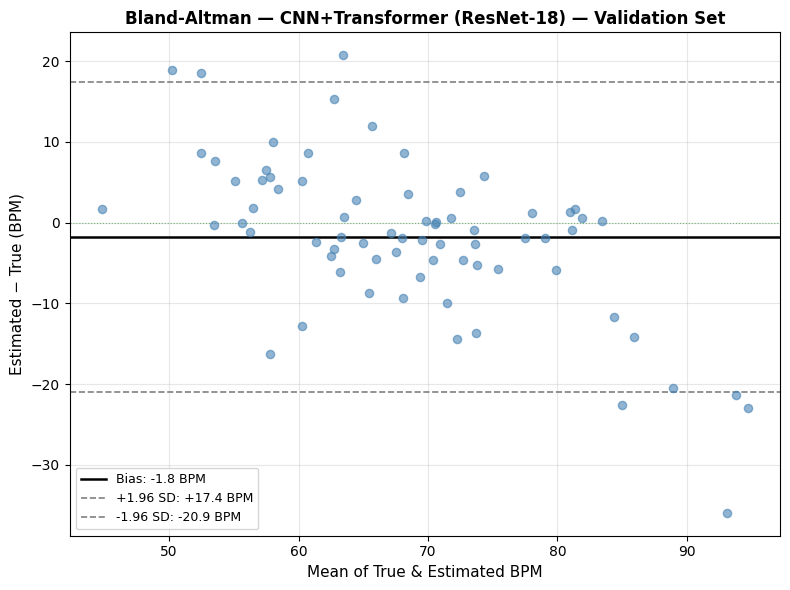

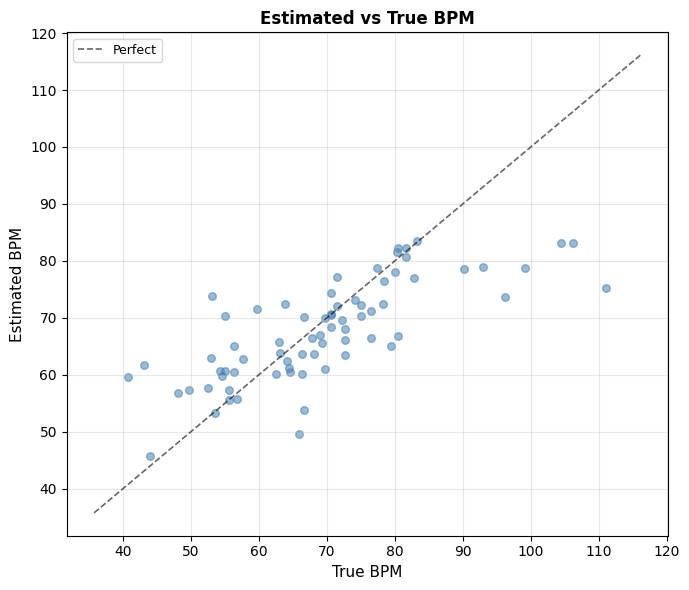

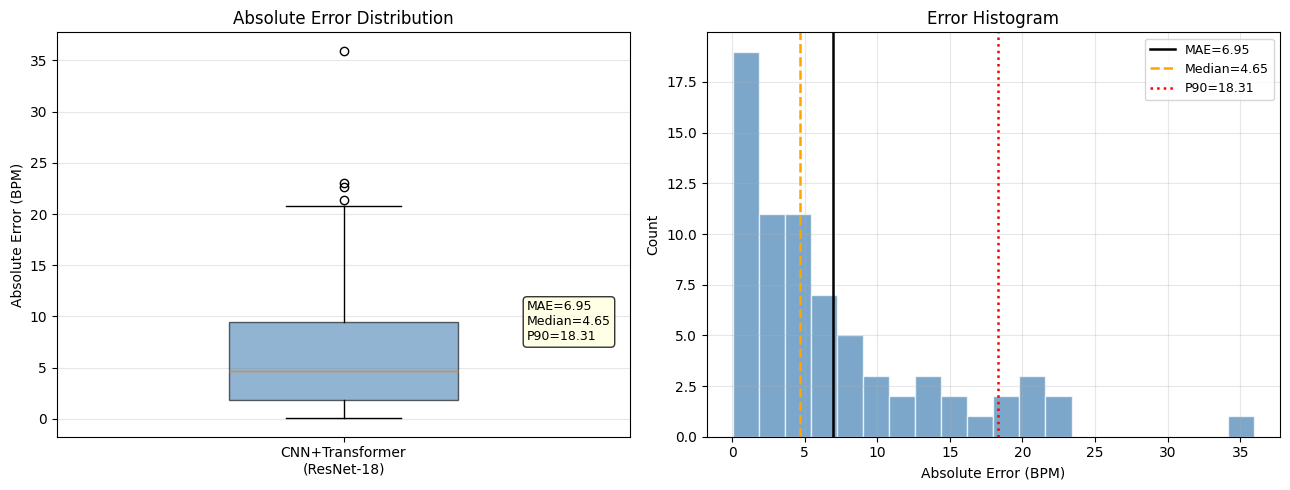

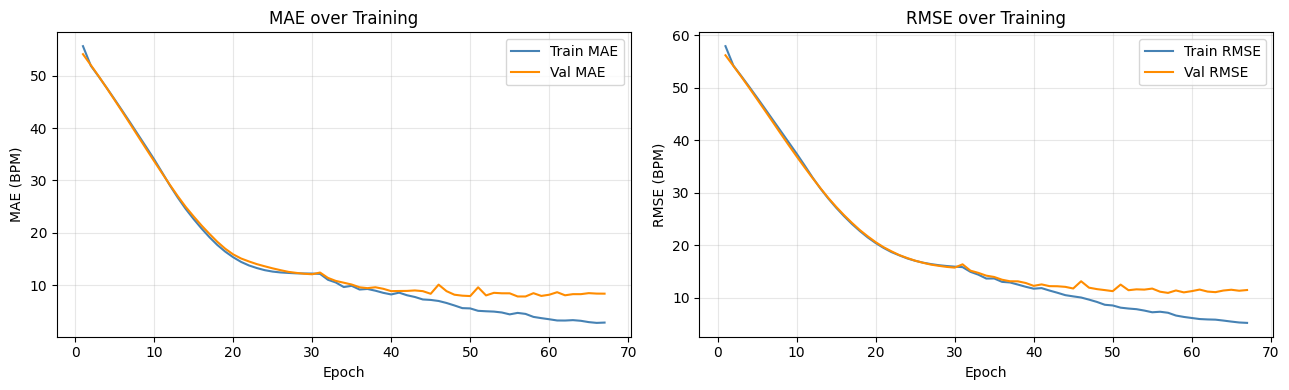


All plots saved → /content/drive/MyDrive/echonet_project/resnet_transformer/val_plots


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ── 1. Load best checkpoint ──────────────────────────────────────────────────
ckpt_path = Path(OUTPUT_DIR) / 'best_model.pt'
eval_model = HRTransformer().to(DEVICE)
eval_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
eval_model.eval()
print(f"Loaded best checkpoint from {ckpt_path}")

# ── 2. Inference — one prediction per clip, averaged per video ───────────────
video_preds  = defaultdict(list)
video_labels = {}

with torch.no_grad():
    for s in val_samples:
        flow = np.array(
            np.load(s['cache_path'], mmap_mode='r')[s['flow_start']:s['flow_end']],
            dtype=np.float32
        )
        T = flow.shape[0]
        clip_flows = FRAMES_PER_CLIP - 1
        if T < clip_flows:
            pad  = np.zeros((clip_flows - T, *flow.shape[1:]), dtype=np.float32)
            flow = np.concatenate([flow, pad], axis=0)
        flow   = (flow - flow.mean()) / (flow.std() + 1e-6)
        flow_t = torch.from_numpy(flow).permute(0, 3, 1, 2).unsqueeze(0).to(DEVICE)
        pred   = eval_model(flow_t).item()
        video_preds[s['cache_path']].append(pred)
        video_labels[s['cache_path']] = s['heart_rate']

records = []
for path, preds in video_preds.items():
    true_bpm = video_labels[path]
    est_bpm  = float(np.mean(preds))
    records.append({
        'video'    : Path(path).stem,
        'true_bpm' : true_bpm,
        'est_bpm'  : est_bpm,
        'abs_err'  : abs(est_bpm - true_bpm),
        'pct_err'  : abs(est_bpm - true_bpm) / true_bpm * 100,
    })

df       = pd.DataFrame(records)
true_bpm = df['true_bpm'].values
est_bpm  = df['est_bpm'].values
abs_err  = df['abs_err'].values
diff     = est_bpm - true_bpm
mean_val = (true_bpm + est_bpm) / 2
bias     = diff.mean()
sd       = diff.std()

mae    = abs_err.mean()
median = np.median(abs_err)
p90    = np.percentile(abs_err, 90)
mape   = df['pct_err'].mean()
rmse   = float(np.sqrt((abs_err ** 2).mean()))
n      = len(df)

print("\n" + "=" * 55)
print("VALIDATION RESULTS — CNN+Transformer (ResNet-18)")
print("=" * 55)
print(f"  N          : {n}")
print(f"  MAE        : {mae:.2f} BPM")
print(f"  Median AE  : {median:.2f} BPM")
print(f"  P90 AE     : {p90:.2f} BPM")
print(f"  MAPE       : {mape:.2f}%")
print(f"  RMSE       : {rmse:.2f} BPM")
print("=" * 55)

summary = pd.DataFrame([{
    'Method'          : 'CNN+Transformer (ResNet-18)',
    'N'               : n,
    'MAE (BPM)'       : mae,
    'Median AE (BPM)' : median,
    'P90 AE (BPM)'    : p90,
    'MAPE (%)'        : mape,
    'RMSE (BPM)'      : rmse,
}]).set_index('Method')
summary.to_csv(Path(OUTPUT_DIR) / 'val_metrics_summary.csv')

# ── 3. Plots ─────────────────────────────────────────────────────────────────
VAL_PLOTS = Path(OUTPUT_DIR) / 'val_plots'
VAL_PLOTS.mkdir(exist_ok=True)

# 3a. Bland-Altman
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(mean_val, diff, alpha=0.6, s=35, color='steelblue', zorder=3)
ax.axhline(bias,             color='black', linewidth=1.8, label=f'Bias: {bias:+.1f} BPM')
ax.axhline(bias + 1.96 * sd, color='gray',  linestyle='--', linewidth=1.2,
           label=f'+1.96 SD: {bias+1.96*sd:+.1f} BPM')
ax.axhline(bias - 1.96 * sd, color='gray',  linestyle='--', linewidth=1.2,
           label=f'-1.96 SD: {bias-1.96*sd:+.1f} BPM')
ax.axhline(0, color='green', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xlabel('Mean of True & Estimated BPM', fontsize=11)
ax.set_ylabel('Estimated − True (BPM)', fontsize=11)
ax.set_title('Bland-Altman — CNN+Transformer (ResNet-18) — Validation Set', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VAL_PLOTS / 'bland_altman.png', dpi=150, bbox_inches='tight')
plt.show()

# 3b. Estimated vs True scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(true_bpm, est_bpm, alpha=0.55, s=30, color='steelblue')
lo, hi = true_bpm.min() - 5, true_bpm.max() + 5
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, alpha=0.6, label='Perfect')
ax.set_xlabel('True BPM', fontsize=11); ax.set_ylabel('Estimated BPM', fontsize=11)
ax.set_title('Estimated vs True BPM', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VAL_PLOTS / 'scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# 3c. Error distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
bp = ax.boxplot(abs_err, patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.6)
ax.set_xticks([1]); ax.set_xticklabels(['CNN+Transformer\n(ResNet-18)'])
ax.set_ylabel('Absolute Error (BPM)'); ax.set_title('Absolute Error Distribution')
ax.text(1.32, np.percentile(abs_err, 75),
        f'MAE={mae:.2f}\nMedian={median:.2f}\nP90={p90:.2f}',
        fontsize=9, va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.hist(abs_err, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(mae,    color='black',  linestyle='-',  linewidth=1.8, label=f'MAE={mae:.2f}')
ax.axvline(median, color='orange', linestyle='--', linewidth=1.8, label=f'Median={median:.2f}')
ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.8, label=f'P90={p90:.2f}')
ax.set_xlabel('Absolute Error (BPM)'); ax.set_ylabel('Count')
ax.set_title('Error Histogram'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VAL_PLOTS / 'error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# 3d. Training curves
hist_path = Path(OUTPUT_DIR) / 'training_history.csv'
if hist_path.exists():
    hist = pd.read_csv(hist_path)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(hist['epoch'], hist['train_mae'],  label='Train MAE',  color='steelblue')
    axes[0].plot(hist['epoch'], hist['val_mae'],    label='Val MAE',    color='darkorange')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE (BPM)')
    axes[0].set_title('MAE over Training'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist['epoch'], hist['train_rmse'], label='Train RMSE', color='steelblue')
    axes[1].plot(hist['epoch'], hist['val_rmse'],   label='Val RMSE',   color='darkorange')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('RMSE (BPM)')
    axes[1].set_title('RMSE over Training'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(VAL_PLOTS / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nAll plots saved → {VAL_PLOTS}")